<a href="https://colab.research.google.com/github/RiccoFlores/100-Days-Of-ML-Code/blob/master/NB4_4_Embeddings_Estudiantes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NB4.4 Embeddings

En la libreta anterior, el texto se representó mediante conteos, n-gramas y TF-IDF. Estas representaciones son útiles e interpretables, pero tienen una limitación importante: no capturan de forma directa la cercanía semántica entre palabras.

Un embedding es una representación densa en la que palabras, frases o documentos se ubican como vectores en un espacio numérico. La idea es que elementos con significados o usos parecidos queden cerca entre sí.

Al finalizar, podrás:

- Explicar la diferencia entre vectores dispersos y vectores densos.
- Construir embeddings mediante reducción dimensional.
- Usar matrices de coocurrencia y PPMI.
- Entrenar un modelo Skip-gram pequeño.
- Explorar embeddings con similitud coseno.
- Usar embeddings para búsqueda semántica simple.


## 1. Preparación

Usaremos un corpus pequeño y controlado. El objetivo no es producir embeddings de calidad industrial, sino entender los mecanismos principales con código que se pueda inspeccionar.


In [ ]:
import re
import math
import random
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity

random.seed(42)
np.random.seed(42)


In [ ]:
corpus = [
    "the king and queen rule the kingdom",
    "the prince and princess live in the palace",
    "royal families govern ancient kingdoms",
    "the doctor and nurse work in the hospital",
    "medical teams treat patients in the clinic",
    "the engineer builds software systems",
    "data scientists analyze data and train models",
    "machine learning models discover patterns in data",
    "football teams play matches in the stadium",
    "basketball players train and compete in tournaments",
    "paris and berlin are european cities",
    "mexico city and merida are important cities",
    "search engines retrieve relevant documents",
    "text embeddings represent words as vectors",
    "semantic search compares queries and documents"
]


def tokenize(text):
    return re.findall(r"[a-z]+", text.lower())


tokenized = [tokenize(doc) for doc in corpus]

tokenized[:3]


[['the', 'king', 'and', 'queen', 'rule', 'the', 'kingdom'],
 ['the', 'prince', 'and', 'princess', 'live', 'in', 'the', 'palace'],
 ['royal', 'families', 'govern', 'ancient', 'kingdoms']]

## 2. De vectores dispersos a vectores densos

En Bag of Words o TF-IDF, cada dimensión suele corresponder a una palabra del vocabulario. Si el vocabulario tiene 10 000 palabras, cada documento puede tener 10 000 dimensiones. La mayoría de los valores serán cero.

Un embedding normalmente usa muchas menos dimensiones. En lugar de tener una dimensión por palabra, intenta distribuir la información en un espacio compacto. Por eso se le llama representación densa.


In [ ]:
tfidf = TfidfVectorizer(lowercase=True)
X = tfidf.fit_transform(corpus)

print("Matriz TF-IDF:", X.shape)
print("Valores distintos de cero:", X.nnz)
print("Proporción de valores distintos de cero:", X.nnz / (X.shape[0] * X.shape[1]))


Matriz TF-IDF: (15, 69)
Valores distintos de cero: 94
Proporción de valores distintos de cero: 0.09082125603864734


La matriz anterior es dispersa. Hay muchas dimensiones, pero cada documento usa pocas de ellas. La siguiente sección reduce esa matriz a un espacio más pequeño.


## 3. LSA con TF-IDF y SVD

LSA, o análisis semántico latente, aplica reducción dimensional sobre una matriz documento término. Una forma común de hacerlo es usar SVD truncado.

La intuición es que algunos patrones de palabras aparecen juntos en documentos relacionados. Al reducir la dimensión, esos patrones pueden formar componentes latentes que aproximan temas o relaciones semánticas.


In [ ]:
n_components = 5
svd = TruncatedSVD(n_components=n_components, random_state=42)
Z_docs = svd.fit_transform(X)
Z_docs = normalize(Z_docs)

print("Embeddings de documentos:", Z_docs.shape)
print("Varianza explicada acumulada:", svd.explained_variance_ratio_.sum().round(3))


Embeddings de documentos: (15, 5)
Varianza explicada acumulada: 0.418


In [ ]:
doc_similarity = cosine_similarity(Z_docs)
pd.DataFrame(doc_similarity, index=range(len(corpus)), columns=range(len(corpus))).round(2)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,1.00,0.94,0.49,0.94,0.21,0.90,0.04,-0.02,0.21,0.20,0.12,0.11,-0.01,0.45,0.12
1,0.94,1.00,0.21,1.00,0.50,0.74,0.12,0.12,0.50,0.41,0.12,0.11,-0.00,0.18,0.12
2,0.49,0.21,1.00,0.21,-0.69,0.79,0.10,-0.05,-0.69,-0.33,-0.19,-0.20,-0.07,0.99,-0.00
3,0.94,1.00,0.21,1.00,0.50,0.74,0.12,0.12,0.50,0.41,0.12,0.11,-0.00,0.18,0.12
4,0.21,0.50,-0.69,0.50,1.00,-0.13,-0.09,0.10,1.00,0.44,-0.04,-0.03,-0.00,-0.71,-0.03
5,0.90,0.74,0.79,0.74,-0.13,1.00,-0.02,-0.10,-0.13,-0.11,-0.12,-0.14,-0.10,0.75,-0.01
6,0.04,0.12,0.10,0.12,-0.09,-0.02,1.00,0.97,-0.09,0.79,0.08,0.07,-0.01,0.23,0.09
7,-0.02,0.12,-0.05,0.12,0.10,-0.10,0.97,1.00,0.10,0.81,-0.08,-0.09,-0.06,0.08,-0.00
8,0.21,0.50,-0.69,0.50,1.00,-0.13,-0.09,0.10,1.00,0.44,-0.04,-0.03,-0.00,-0.71,-0.03
9,0.20,0.41,-0.33,0.41,0.44,-0.11,0.79,0.81,0.44,1.00,0.35,0.34,0.09,-0.24,0.21


Después de SVD, cada documento queda representado con menos dimensiones. Podemos buscar documentos cercanos en este nuevo espacio.


In [ ]:
def nearest_documents(doc_id, vectors, documents, top_k=4):
    scores = cosine_similarity(vectors[doc_id:doc_id+1], vectors).ravel()
    ranking = np.argsort(scores)[::-1]
    rows = []
    for idx in ranking[1:top_k+1]:
        rows.append({"document_id": int(idx), "score": float(scores[idx]), "document": documents[idx]})
    return pd.DataFrame(rows)

nearest_documents(6, Z_docs, corpus)


,document_id,score,document
0,7,0.965262,machine learning models discover patterns in data
1,9,0.794911,basketball players train and compete in tourna...
2,13,0.232704,text embeddings represent words as vectors
3,3,0.119055,the doctor and nurse work in the hospital


También podemos obtener vectores para términos. En este caso, los componentes aprendidos por SVD permiten ubicar palabras en el mismo espacio reducido.


In [ ]:
terms = tfidf.get_feature_names_out()
Z_terms = normalize(svd.components_.T)


def nearest_terms(term, term_vectors, terms, top_k=8):
    if term not in terms:
        return pd.DataFrame()
    idx = list(terms).index(term)
    scores = cosine_similarity(term_vectors[idx:idx+1], term_vectors).ravel()
    ranking = np.argsort(scores)[::-1]
    rows = []
    for j in ranking[1:top_k+1]:
        rows.append({"term": terms[j], "score": float(scores[j])})
    return pd.DataFrame(rows)

nearest_terms("data", Z_terms, terms)


,term,score
0,models,0.998669
1,analyze,0.994778
2,scientists,0.994778
3,discover,0.979057
4,patterns,0.979057
5,learning,0.979057
6,machine,0.979057
7,train,0.971200


## 4. Matriz de coocurrencia

Otra forma de construir significado es observar contexto. Si dos palabras aparecen cerca de palabras parecidas, es probable que estén relacionadas.

Una matriz de coocurrencia cuenta cuántas veces aparece una palabra cerca de otra dentro de una ventana de contexto.


In [ ]:
vocab = sorted(set(token for doc in tokenized for token in doc))
tok2id = {tok: i for i, tok in enumerate(vocab)}
id2tok = {i: tok for tok, i in tok2id.items()}

window_size = 2
cooc = np.zeros((len(vocab), len(vocab)), dtype=np.float64)

for doc in tokenized:
    for center_pos, center_word in enumerate(doc):
        center_id = tok2id[center_word]
        start = max(0, center_pos - window_size)
        end = min(len(doc), center_pos + window_size + 1)
        for context_pos in range(start, end):
            if context_pos == center_pos:
                continue
            context_word = doc[context_pos]
            context_id = tok2id[context_word]
            cooc[center_id, context_id] += 1

cooc_df = pd.DataFrame(cooc, index=vocab, columns=vocab)
cooc_df.loc[["king", "queen", "data", "models"], ["the", "and", "royal", "data", "models"]]


,the,and,royal,data,models
king,1.0,1.0,0.0,0.0,0.0
queen,1.0,1.0,0.0,0.0,0.0
data,0.0,1.0,0.0,0.0,0.0
models,0.0,1.0,0.0,0.0,0.0


La matriz de coocurrencia todavía está basada en conteos. Sin embargo, ya introduce una idea importante: el significado de una palabra puede aproximarse a partir de los contextos en los que aparece.


## 5. PPMI

PPMI significa Positive Pointwise Mutual Information. Esta medida compara la coocurrencia observada entre dos palabras contra la coocurrencia esperada si fueran independientes.

Si dos palabras aparecen juntas más de lo esperado, el valor PPMI será alto. Si no hay evidencia positiva de asociación, el valor se deja en cero.


In [ ]:
def compute_ppmi(matrix):
    total = matrix.sum()
    row_sums = matrix.sum(axis=1, keepdims=True)
    col_sums = matrix.sum(axis=0, keepdims=True)
    expected = row_sums @ col_sums / total
    with np.errstate(divide="ignore", invalid="ignore"):
        pmi = np.log2((matrix * total) / expected)
    pmi[np.isinf(pmi)] = 0
    pmi[np.isnan(pmi)] = 0
    return np.maximum(pmi, 0)

ppmi = compute_ppmi(cooc)
ppmi_df = pd.DataFrame(ppmi, index=vocab, columns=vocab)
ppmi_df.loc[["king", "queen", "data", "models"], ["the", "and", "royal", "data", "models"]].round(2)


,the,and,royal,data,models
king,10.37,9.98,0.0,0.0,0.0
queen,9.95,9.57,0.0,0.0,0.0
data,0.00,8.57,0.0,0.0,0.0
models,0.00,8.98,0.0,0.0,0.0


PPMI reduce el efecto de palabras muy frecuentes y resalta asociaciones contextuales. A partir de esta matriz también podemos construir embeddings usando reducción dimensional.


## 6. Embeddings desde PPMI con SVD

Aplicaremos SVD sobre la matriz PPMI. El resultado será un vector denso para cada palabra del vocabulario.


In [ ]:
dim = min(10, len(vocab) - 1)
svd_ppmi = TruncatedSVD(n_components=dim, random_state=42)
W_ppmi = svd_ppmi.fit_transform(ppmi)
W_ppmi = normalize(W_ppmi)

print("Embeddings de palabras:", W_ppmi.shape)


Embeddings de palabras: (69, 10)


In [ ]:
def nearest_words(word, vectors, vocabulary, top_k=8):
    if word not in vocabulary:
        return pd.DataFrame()
    idx = vocabulary.index(word)
    scores = cosine_similarity(vectors[idx:idx+1], vectors).ravel()
    ranking = np.argsort(scores)[::-1]
    rows = []
    for j in ranking[1:top_k+1]:
        rows.append({"word": vocabulary[j], "score": float(scores[j])})
    return pd.DataFrame(rows)

nearest_words("king", W_ppmi, vocab)


,word,score
0,rule,0.979329
1,queen,0.960216
2,doctor,0.953717
3,prince,0.953670
4,live,0.888413
5,work,0.888397
6,kingdom,0.733490
7,engineer,0.726966


In [ ]:
nearest_words("data", W_ppmi, vocab)


,word,score
0,compete,0.966692
1,players,0.834254
2,models,0.825933
3,discover,0.816638
4,nurse,0.793730
5,princess,0.793713
6,analyze,0.740811
7,patterns,0.660879


En un corpus pequeño los vecinos pueden ser inestables. Lo importante es observar el procedimiento: construir contextos, ponderar asociaciones y reducir dimensión.


## 7. Skip-gram con PyTorch

Word2Vec propone aprender embeddings mediante una tarea de predicción. En Skip-gram, el modelo recibe una palabra central y trata de predecir palabras cercanas en su contexto.

Por ejemplo, en la frase `the king and queen rule`, si la palabra central es `king`, algunas palabras de contexto pueden ser `the`, `and` y `queen`, dependiendo del tamaño de ventana.


In [ ]:
pairs = []
for doc in tokenized:
    for center_pos, center_word in enumerate(doc):
        center_id = tok2id[center_word]
        start = max(0, center_pos - window_size)
        end = min(len(doc), center_pos + window_size + 1)
        for context_pos in range(start, end):
            if context_pos == center_pos:
                continue
            context_word = doc[context_pos]
            context_id = tok2id[context_word]
            pairs.append((center_id, context_id))

print("Número de pares centro contexto:", len(pairs))
print([(id2tok[c], id2tok[o]) for c, o in pairs[:12]])


Número de pares centro contexto: 302
[('the', 'king'), ('the', 'and'), ('king', 'the'), ('king', 'and'), ('king', 'queen'), ('and', 'the'), ('and', 'king'), ('and', 'queen'), ('and', 'rule'), ('queen', 'king'), ('queen', 'and'), ('queen', 'rule')]


In [ ]:
try:
    import torch
    from torch import nn
    from torch.utils.data import Dataset, DataLoader
    TORCH_AVAILABLE = True
except ImportError:
    TORCH_AVAILABLE = False

TORCH_AVAILABLE


True

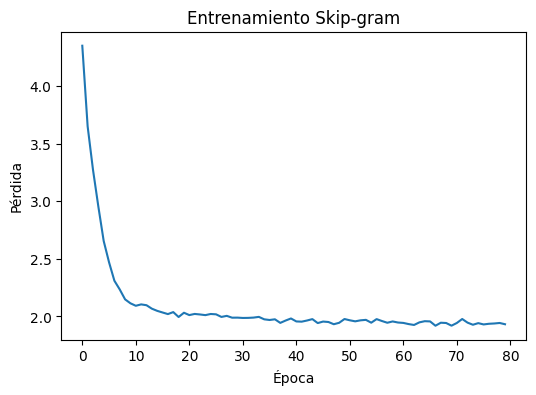

In [ ]:
if TORCH_AVAILABLE:
    class SkipGramDataset(Dataset):
        def __init__(self, pairs):
            self.pairs = pairs

        def __len__(self):
            return len(self.pairs)

        def __getitem__(self, idx):
            center, context = self.pairs[idx]
            return torch.tensor(center), torch.tensor(context)


    class SkipGramModel(nn.Module):
        def __init__(self, vocab_size, embedding_dim):
            super().__init__()
            self.embedding = nn.Embedding(vocab_size, embedding_dim)
            self.output = nn.Linear(embedding_dim, vocab_size)

        def forward(self, center_words):
            embedded = self.embedding(center_words)
            return self.output(embedded)


    dataset = SkipGramDataset(pairs)
    dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

    model = SkipGramModel(len(vocab), embedding_dim=12)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.03)
    loss_fn = nn.CrossEntropyLoss()

    losses = []
    for epoch in range(80):
        total_loss = 0
        for centers, contexts in dataloader:
            optimizer.zero_grad()
            logits = model(centers)
            loss = loss_fn(logits, contexts)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        losses.append(total_loss / len(dataloader))

    plt.figure(figsize=(6, 4))
    plt.plot(losses)
    plt.xlabel("Época")
    plt.ylabel("Pérdida")
    plt.title("Entrenamiento Skip-gram")
    plt.show()
else:
    print("PyTorch no está instalado en este entorno.")


In [ ]:
if TORCH_AVAILABLE:
    W_sg = model.embedding.weight.detach().numpy()
    W_sg = normalize(W_sg)
    display(nearest_words("king", W_sg, vocab))


,word,score
0,rule,0.853626
1,doctor,0.599130
2,work,0.578001
3,paris,0.567967
4,engineer,0.564037
5,hospital,0.530835
6,systems,0.436080
7,palace,0.412385


In [ ]:
W_sg[0]

array([-0.04726523, -0.01028386, -0.5764789 ,  0.10841732,  0.20533115,
       -0.4279082 ,  0.3153048 ,  0.0321717 , -0.24895014,  0.29643214,
       -0.32633775,  0.2674227 ], dtype=float32)

El entrenamiento anterior es pequeño y solo sirve con fines didácticos. En aplicaciones reales se usan corpus mucho más grandes, muestreo negativo, mayor control de hiperparámetros y evaluación más rigurosa.


## 8. Subword embeddings

Una limitación de los embeddings por palabra completa es que no aprovechan la estructura interna de las palabras. Los modelos subword representan una palabra a partir de fragmentos de caracteres.

Esto puede ayudar con palabras raras, errores de escritura o variantes morfológicas. Por ejemplo, `model`, `models` y `modeling` comparten fragmentos.


In [ ]:
def char_ngrams(word, n_min=3, n_max=5):
    word = f"<{word}>"
    grams = []
    for n in range(n_min, n_max + 1):
        for i in range(len(word) - n + 1):
            grams.append(word[i:i+n])
    return grams

char_ngrams("models")[:12]


['<mo',
 'mod',
 'ode',
 'del',
 'els',
 'ls>',
 '<mod',
 'mode',
 'odel',
 'dels',
 'els>',
 '<mode']

In [ ]:
subword_vocab = sorted(set(gram for word in vocab for gram in char_ngrams(word)))
subword_index = {gram: i for i, gram in enumerate(subword_vocab)}

subword_matrix = np.zeros((len(vocab), len(subword_vocab)))
for word_id, word in enumerate(vocab):
    for gram in char_ngrams(word):
        subword_matrix[word_id, subword_index[gram]] += 1

subword_matrix = normalize(subword_matrix)
nearest_words("models", subword_matrix, vocab)


,word,score
0,words,0.0
1,vectors,0.0
2,treat,0.0
3,work,0.0
4,train,0.0
5,tournaments,0.0
6,text,0.0
7,the,0.0


Este ejemplo no aprende significado por contexto. Solo muestra cómo los fragmentos de caracteres pueden producir cercanía entre palabras con formas parecidas.


## 9. Búsqueda semántica con embeddings de documentos

Para representar documentos con embeddings simples, podemos promediar los vectores de las palabras que aparecen en cada documento. Este enfoque es básico, pero permite construir una búsqueda semántica inicial.


In [ ]:
def document_embedding(tokens, word_vectors, vocabulary):
    vectors = []
    for token in tokens:
        if token in vocabulary:
            vectors.append(word_vectors[vocabulary.index(token)])
    if not vectors:
        return np.zeros(word_vectors.shape[1])
    return np.mean(vectors, axis=0)


doc_embeddings = np.vstack([
    document_embedding(tokens, W_ppmi, vocab)
    for tokens in tokenized
])
doc_embeddings = normalize(doc_embeddings)

print(doc_embeddings.shape)


(15, 10)


In [ ]:
def semantic_search(query, word_vectors, vocabulary, documents, top_k=5):
    query_tokens = tokenize(query)
    query_vector = document_embedding(query_tokens, word_vectors, vocabulary).reshape(1, -1)
    query_vector = normalize(query_vector)
    scores = cosine_similarity(query_vector, doc_embeddings).ravel()
    ranking = np.argsort(scores)[::-1]
    rows = []
    for idx in ranking[:top_k]:
        rows.append({"document_id": int(idx), "score": float(scores[idx]), "document": documents[idx]})
    return pd.DataFrame(rows)

semantic_search("software and data models", W_ppmi, vocab, corpus)


,document_id,score,document
0,9,0.897680,basketball players train and compete in tourna...
1,6,0.854690,data scientists analyze data and train models
2,3,0.791174,the doctor and nurse work in the hospital
3,1,0.791157,the prince and princess live in the palace
4,7,0.715542,machine learning models discover patterns in data


In [ ]:
semantic_search("royal palace and kingdom", W_ppmi, vocab, corpus)


,document_id,score,document
0,0,0.725022,the king and queen rule the kingdom
1,1,0.712660,the prince and princess live in the palace
2,3,0.712637,the doctor and nurse work in the hospital
3,5,0.518605,the engineer builds software systems
4,9,0.480219,basketball players train and compete in tourna...


El resultado depende mucho del corpus y del método usado para construir los vectores. Aun así, el ejemplo muestra cómo los embeddings permiten comparar consultas y documentos en un espacio común.


## 10. Sesgo y evaluación

Los embeddings aprenden patrones presentes en los datos. Si un corpus contiene asociaciones sesgadas, los vectores pueden reflejarlas. Por eso no basta con entrenar o descargar embeddings; también es necesario evaluarlos de acuerdo con el contexto de uso.

En un sistema real conviene revisar al menos tres aspectos:

- Calidad de vecinos semánticos para términos relevantes.
- Desempeño en la tarea final, por ejemplo búsqueda o clasificación.
- Asociaciones no deseadas relacionadas con género, origen, profesión, edad u otras dimensiones sensibles.


In [ ]:
for word in ["doctor", "nurse", "engineer", "data", "king", "queen"]:
    print("\n", word)
    display(nearest_words(word, W_ppmi, vocab, top_k=5))



 doctor


,word,score
0,prince,1.000000
1,king,0.953717
2,rule,0.883413
3,live,0.877045
4,work,0.876986



 nurse


,word,score
0,princess,1.000000
1,compete,0.853390
2,data,0.793730
3,the,0.717447
4,tournaments,0.656297



 engineer


...

,word,score
0,compete,0.966692
1,players,0.834254
2,models,0.825933
3,discover,0.816638
4,nurse,0.793730



 king


,word,score
0,rule,0.979329
1,queen,0.960216
2,doctor,0.953717
3,prince,0.953670
4,live,0.888413



 queen


,word,score
0,rule,0.968615
1,king,0.960216
2,doctor,0.875878
3,prince,0.875829
4,live,0.839170


## 11. Actividad

Realiza las siguientes modificaciones:

1. Agrega documentos nuevos al corpus sobre un tema de tu interés.
2. Vuelve a construir la matriz de coocurrencia y la matriz PPMI.
3. Calcula embeddings con SVD.
4. Busca los vecinos de tres palabras importantes en tu corpus.
5. Escribe una interpretación breve de los resultados.

Preguntas guía:

- ¿Los vecinos encontrados tienen sentido?
- ¿Qué palabras aparecen cercanas por significado y cuáles por coincidencia del corpus?
- ¿Qué pasaría si el corpus fuera más grande y diverso?
